# Acompanhamento 1 - Estrategia de Limpeza de Dados

Este notebook documenta e testa uma estrategia inicial de limpeza para a base de precos de imoveis. O objetivo e deixar claro como tratar nulos, tipos, categorias e outliers antes da modelagem. Nenhum modelo final e treinado aqui, pois isso pertence ao acompanhamento 2.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('data')
TRAIN_PATH = DATA_DIR / 'treino.csv'
TEST_PATH = DATA_DIR / 'teste_publico.csv'
RANDOM_STATE = 42

In [2]:
treino = pd.read_csv(TRAIN_PATH)
teste_publico = pd.read_csv(TEST_PATH)

print(f'Treino: {treino.shape}')
print(f'Teste publico: {teste_publico.shape}')

Treino: (1168, 81)
Teste publico: (1459, 80)


## Regras de limpeza propostas

1. Preservar `Id` apenas como identificador; nao usar como sinal preditivo.
2. Tratar nulos que significam ausencia do atributo como categoria `None`, seguindo o dicionario de dados.
3. Preencher medidas numericas associadas a atributos ausentes com `0`, como area de alvenaria, ano/area de garagem e areas/banheiros de porao quando aplicavel.
4. Imputar `LotFrontage` pela mediana do bairro (`Neighborhood`), pois fachada tende a variar por localizacao.
5. Para poucos nulos residuais em categoricas, usar moda calculada no treino.
6. Para poucos nulos residuais em numericas, usar mediana calculada no treino.
7. Marcar outliers para acompanhamento; no pipeline futuro, preferir transformacoes robustas/log ou winsorizacao documentada a remocao cega.

In [3]:
none_category_cols = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
zero_numeric_cols = [
    'MasVnrArea', 'GarageYrBlt', 'GarageCars', 'GarageArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath'
]

existing_none_cols = [c for c in none_category_cols if c in treino.columns]
existing_zero_cols = [c for c in zero_numeric_cols if c in treino.columns]

print('Categoricas preenchidas com None:', existing_none_cols)
print('Numericas preenchidas com 0:', existing_zero_cols)

Categoricas preenchidas com None: ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']
Numericas preenchidas com 0: ['MasVnrArea', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']


In [4]:
def fit_cleaning_statistics(train_df):
    stats = {}
    lot_by_neighborhood = train_df.groupby('Neighborhood')['LotFrontage'].median()
    stats['lot_by_neighborhood'] = lot_by_neighborhood
    stats['lot_global_median'] = train_df['LotFrontage'].median()

    cat_cols = train_df.select_dtypes(exclude=np.number).columns.tolist()
    num_cols = train_df.select_dtypes(include=np.number).columns.tolist()

    stats['categorical_modes'] = {
        col: train_df[col].mode(dropna=True).iloc[0]
        for col in cat_cols
        if train_df[col].notna().any()
    }
    stats['numeric_medians'] = {
        col: train_df[col].median()
        for col in num_cols
        if col not in ['SalePrice'] and train_df[col].notna().any()
    }
    return stats


def apply_cleaning_strategy(df, stats):
    cleaned = df.copy()

    for col in existing_none_cols:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].fillna('None')

    for col in existing_zero_cols:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].fillna(0)

    if 'LotFrontage' in cleaned.columns:
        by_neighborhood = cleaned['Neighborhood'].map(stats['lot_by_neighborhood'])
        cleaned['LotFrontage'] = cleaned['LotFrontage'].fillna(by_neighborhood)
        cleaned['LotFrontage'] = cleaned['LotFrontage'].fillna(stats['lot_global_median'])

    for col, mode in stats['categorical_modes'].items():
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].fillna(mode)

    for col, median in stats['numeric_medians'].items():
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].fillna(median)

    return cleaned

cleaning_stats = fit_cleaning_statistics(treino)
treino_limpo = apply_cleaning_strategy(treino, cleaning_stats)
teste_limpo = apply_cleaning_strategy(teste_publico, cleaning_stats)

## Validacao dos nulos apos a limpeza

A estrategia deve ser ajustada no pipeline final, mas este teste mostra que as regras propostas conseguem tratar os nulos em treino e teste publico usando estatisticas aprendidas somente no treino.

In [5]:
resumo_nulos = pd.DataFrame({
    'nulos_treino_antes': treino.isna().sum(),
    'nulos_treino_depois': treino_limpo.isna().sum(),
}).join(pd.DataFrame({
    'nulos_teste_antes': teste_publico.isna().sum(),
    'nulos_teste_depois': teste_limpo.isna().sum(),
}), how='outer').fillna(0).astype(int)

resumo_nulos[(resumo_nulos > 0).any(axis=1)].sort_values('nulos_treino_antes', ascending=False).head(30)

,nulos_treino_antes,nulos_treino_depois,nulos_teste_antes,nulos_teste_depois
PoolQC,1162,0,1456,0
MiscFeature,1122,0,1408,0
Alley,1094,0,1352,0
Fence,935,0,1169,0
MasVnrType,683,0,894,0
FireplaceQu,547,0,730,0
LotFrontage,217,0,227,0
GarageFinish,64,0,78,0
GarageCond,64,0,78,0
GarageYrBlt,64,0,78,0


In [6]:
print('Total de nulos no treino antes:', int(treino.isna().sum().sum()))
print('Total de nulos no treino depois:', int(treino_limpo.isna().sum().sum()))
print('Total de nulos no teste antes:', int(teste_publico.isna().sum().sum()))
print('Total de nulos no teste depois:', int(teste_limpo.isna().sum().sum()))

Total de nulos no treino antes: 6227
Total de nulos no treino depois: 0
Total de nulos no teste antes: 7878
Total de nulos no teste depois: 0


## Conferencia de variaveis com NA semantico

O tratamento com `None` preserva informacao de ausencia. Por exemplo, uma casa sem piscina continua carregando a informacao `PoolQC = None`, em vez de perder a coluna ou receber uma categoria artificial sem sentido.

In [7]:
semantic_na_summary = []
for col in existing_none_cols:
    semantic_na_summary.append({
        'coluna': col,
        'nulos_originais': int(treino[col].isna().sum()),
        'qtd_None_apos_limpeza': int((treino_limpo[col] == 'None').sum()),
        'valores_distintos_apos_limpeza': int(treino_limpo[col].nunique(dropna=False)),
    })

pd.DataFrame(semantic_na_summary).sort_values('nulos_originais', ascending=False)

,coluna,nulos_originais,qtd_None_apos_limpeza,valores_distintos_apos_limpeza
11,PoolQC,1162,1162,4
13,MiscFeature,1122,1122,5
0,Alley,1094,1094,3
12,Fence,935,935,5
14,MasVnrType,683,683,4
6,FireplaceQu,547,547,6
10,GarageCond,64,64,6
8,GarageFinish,64,64,4
9,GarageQual,64,64,6
7,GarageType,64,64,7


## Outliers: politica inicial

Para o acompanhamento 1, os outliers sao diagnosticados e documentados. A recomendacao e nao remove-los automaticamente antes de avaliar impacto em validacao, porque imoveis caros, grandes ou em bairros valorizados podem ser observacoes reais.

In [8]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        rows.append({
            'coluna': col,
            'limite_inferior': round(lower, 2),
            'limite_superior': round(upper, 2),
            'qtd_outliers': int(mask.sum()),
            'pct_outliers': round(mask.mean() * 100, 2),
        })
    return pd.DataFrame(rows).sort_values('qtd_outliers', ascending=False)

outlier_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', '1stFlrSF']
iqr_outlier_summary(treino_limpo, outlier_cols)

,coluna,limite_inferior,limite_superior,qtd_outliers,pct_outliers
4,LotArea,1418.12,17869.12,54,4.62
0,SalePrice,2612.50,342312.50,48,4.11
2,TotalBsmtSF,41.12,2054.12,47,4.02
1,GrLivArea,176.38,2761.38,23,1.97
3,GarageArea,-11.50,928.50,18,1.54
5,1stFlrSF,124.88,2159.88,13,1.11


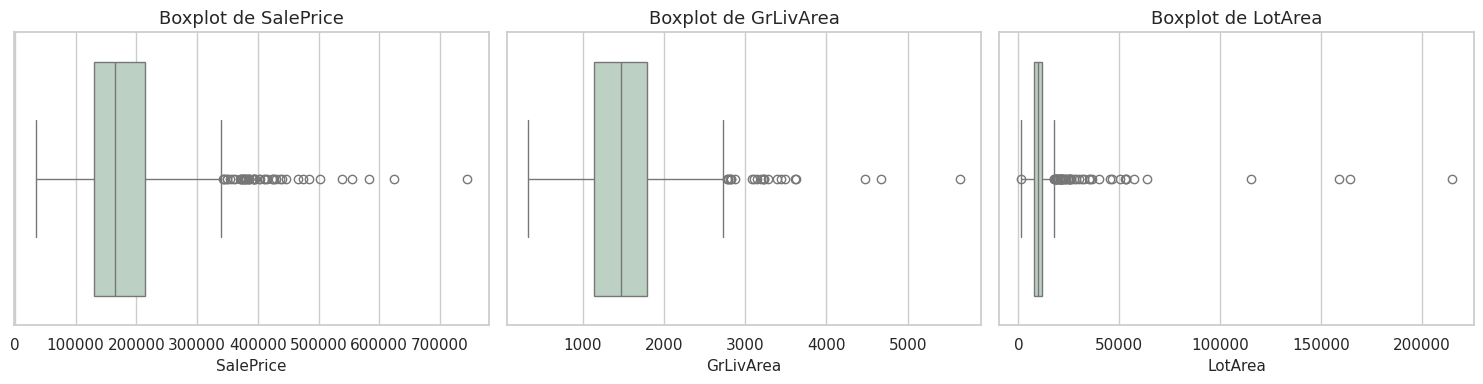

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['SalePrice', 'GrLivArea', 'LotArea']):
    sns.boxplot(x=treino_limpo[col], ax=ax, color='#b9d3c2')
    ax.set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

## Preparacao para o acompanhamento 2

A limpeza acima deve ser migrada para um `Pipeline`/`ColumnTransformer` no acompanhamento 2, com `OneHotEncoder(handle_unknown='ignore')` para categoricas e imputadores ajustados somente no treino. O alvo deve ser tratado em escala logaritmica durante modelagem e convertido de volta para dolares ao gerar predicoes.

In [10]:
checklist = pd.DataFrame([
    {'item': 'Usar estatisticas calculadas somente no treino', 'status': 'planejado'},
    {'item': 'Transformar SalePrice com log1p na modelagem', 'status': 'planejado'},
    {'item': 'Codificar categoricas com handle_unknown=ignore', 'status': 'planejado'},
    {'item': 'Manter Id fora das features preditivas', 'status': 'planejado'},
    {'item': 'Avaliar outliers com validacao antes de remover', 'status': 'planejado'},
    {'item': 'Comparar RMSLE, MAE em dolares e R2', 'status': 'planejado'},
])
checklist

,item,status
0,Usar estatisticas calculadas somente no treino,planejado
1,Transformar SalePrice com log1p na modelagem,planejado
2,Codificar categoricas com handle_unknown=ignore,planejado
3,Manter Id fora das features preditivas,planejado
4,Avaliar outliers com validacao antes de remover,planejado
5,"Comparar RMSLE, MAE em dolares e R2",planejado


## Sintese da estrategia de limpeza

- Nulos que representam ausencia fisica do atributo serao preenchidos com `None` ou `0`, conforme o tipo da coluna.
- `LotFrontage` sera imputada por mediana do bairro e, se necessario, pela mediana global do treino.
- Nulos residuais categoricos serao preenchidos pela moda do treino; numericos residuais, pela mediana do treino.
- Outliers serao tratados inicialmente por transformacoes robustas/log e avaliacao em validacao, nao por exclusao automatica.
- A implementacao final deve ser encapsulada no pipeline para evitar vazamento de dados.